In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import digamma
from scipy.optimize import fsolve

In [3]:
data = np.loadtxt('whales.txt')
n = len(data)
print(f"n = {n} observations")
print(f"Mean  = {data.mean():.4f}")
print(f"Var   = {data.var(ddof=1):.4f}")

n = 210 observations
Mean  = 0.6060
Var   = 0.4617


In [9]:
# (b)  Method of Moments
xbar = data.mean()
s2   = data.var(ddof=1)          # unbiased sample variance

beta_mom  = xbar / s2            # rate  (1/scale)
alpha_mom = xbar * beta_mom      # shape

print(f"MoM")
print(f"  α̂  (shape) = {alpha_mom:.4f}")
print(f"  β̂  (rate)  = {beta_mom:.4f}   (scale = {1/beta_mom:.4f})")

MoM
  α̂  (shape) = 0.7954
  β̂  (rate)  = 1.3125   (scale = 0.7619)


In [10]:
# (c)  Maximum Likelihood 

alpha_mle, loc_mle, scale_mle = stats.gamma.fit(data, floc=0)
beta_mle = 1.0 / scale_mle

print(f"MLE")
print(f"  α̂  (shape) = {alpha_mle:.4f}")
print(f"  β̂  (rate)  = {beta_mle:.4f}   (scale = {scale_mle:.4f})")

print(f"Comparison")
print(f"  Δα = {abs(alpha_mle - alpha_mom):.4f}")
print(f"  Δβ = {abs(beta_mle  - beta_mom ):.4f}")

MLE
  α̂  (shape) = 1.5954
  β̂  (rate)  = 2.6327   (scale = 0.3798)
Comparison
  Δα = 0.8000
  Δβ = 1.3202


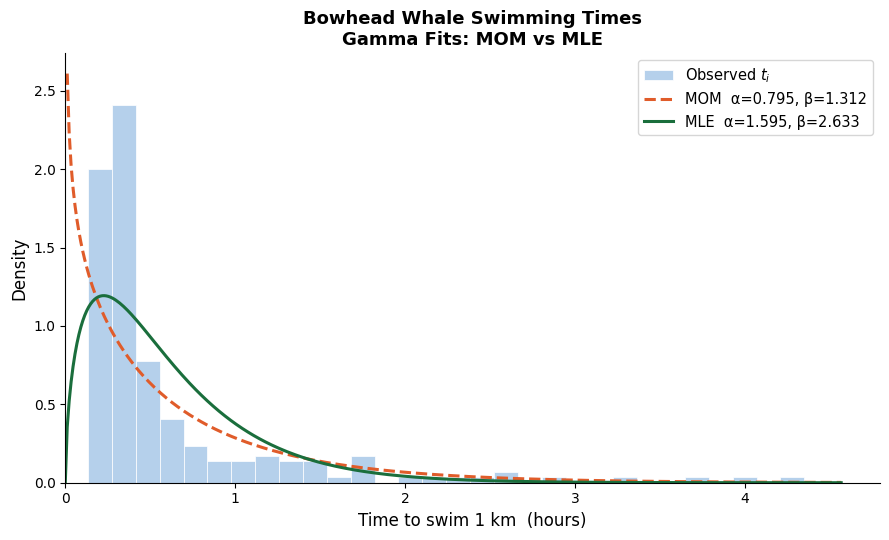


Plot saved.


In [14]:
# (a) and (d)  Histogram and both density curves
fig, ax = plt.subplots(figsize=(9, 5.5))

# histogram (density-normalised)
ax.hist(data, bins=30, density=True, color='#a8c8e8', edgecolor='white',
        linewidth=0.6, alpha=0.85, label='Observed $t_i$')

# x grid for densities
x = np.linspace(0, data.max() * 1.05, 400)

# MOM curve
y_mom = stats.gamma.pdf(x, a=alpha_mom, scale=1/beta_mom)
ax.plot(x, y_mom, color='#e05c2a', linewidth=2.2, linestyle='--',
        label=f'MOM  α={alpha_mom:.3f}, β={beta_mom:.3f}')

# MLE curve
y_mle = stats.gamma.pdf(x, a=alpha_mle, scale=scale_mle)
ax.plot(x, y_mle, color='#1a6e3c', linewidth=2.2,
        label=f'MLE  α={alpha_mle:.3f}, β={beta_mle:.3f}')

ax.set_xlabel('Time to swim 1 km  (hours)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Bowhead Whale Swimming Times\nGamma Fits: MOM vs MLE', fontsize=13, fontweight='bold')
ax.legend(fontsize=10.5)
ax.set_xlim(left=0)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('whale_gamma_fit.png', dpi=150)
plt.show()
print("\nPlot saved.")